In [17]:
from sklearn import linear_model
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error
import pandas as pd
from sklearn.model_selection import train_test_split
import seaborn as sns 



In [11]:
insurance=pd.read_csv("insurance.csv")


X=insurance.drop(columns=["charges"])
y=insurance["charges"]

X=pd.get_dummies(X,columns=["region"],drop_first=True,dtype="int")

X["smoker"]=X["smoker"].map({"yes":1,"no":0})
X["sex"]=X["sex"].map({"female":1,"male":0})

from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42
)


mean square error for alpha0.01 is  33597001.223820455
mean square error for alpha0.1 is  33597770.05720262
mean square error for alpha2 is  33614211.308740854
mean square error for alpha3 is  33623037.56043786
mean square error for alpha4 is  33631952.08146762
mean square error for alpha5 is  33639750.85985903
mean square error for alpha10 is  33679511.30099594
mean square error for alpha20 is  33766604.71529101
mean square error for alpha30 is  33855740.161839
mean square error for alpha40 is  33947018.40367207
mean square error for alpha50 is  34042719.501167394
mean square error for alpha100 is  34245283.94567649


<Axes: >

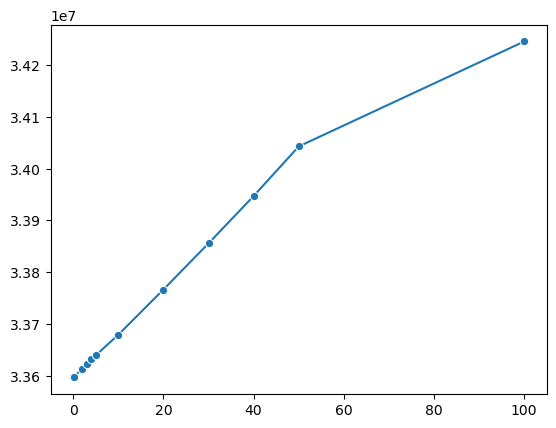

In [19]:
alphas=[0.01,0.1,2,3,4,5,10,20,30,40,50,100]
mses=[]
for a in alphas:
        
    lasso_model=Lasso(alpha=a)
    lasso_model.fit(X_train,y_train)

    y_pred=lasso_model.predict(X_test)

    mse_value=mean_squared_error(y_test,y_pred)
    print(f"mean square error for alpha{a} is ",mse_value)
    mses.append(mse_value)

sns.lineplot(x=alphas,y=mses,marker="o")

In [29]:
from sklearn.linear_model import LassoCV
a=[0.001,0.1,1,2,5,10,20,30,40,50,100]

lasso_cv_model=LassoCV(
    alphas=a,
    cv=5,
    max_iter=1000,
    random_state=42
)

lasso_cv_model.fit(X_train,y_train)

print("Best Alpha:",lasso_cv_model.alpha_)

Best Alpha: 100.0
